In [1]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import pearsonr

#### Données Iris



In [3]:
from sklearn import datasets
iris = datasets.load_iris()

Iris est un dictionnaire contenant plusieurs champs.


In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
# Description des données Iris
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

#### On souhaite prédire l'espèce de l'iris en utilisant ses mesures morphologiques, il s'agit d'un problème de classification.

Les instances sont décrites par ces 4 mesures quantitatives dans \$\\mathbb{R}^4\$. L'ensemble des étiquettes \$Y\$ est composé des 3 espèces d'iris.


In [6]:
# Transformation en dataframe
import pandas as pd
import numpy as np
X = pd.DataFrame(iris.data, columns=['sepal length','sepal width', 'petal length','petal width'])
y = pd.Series(iris.target)

##### Utilisons la fonction sklearn.model\_selection.train\_test\_split pour diviser les données en un ensemble d'entraînement \(100 exemples\) et un ensemble de test \(le reste des exemples\). Utilisons l'argument par défaut shuffle=True

L'option shuffle permet de mélanger les données avant de les séparer en un ensemble de train et un ensemble de test.


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=100)

##### Utilisons  sepal width et petal length comme instances et visualisons les données en les colorant en fonction des classes



<Axes: xlabel='sepal width', ylabel='petal length'>

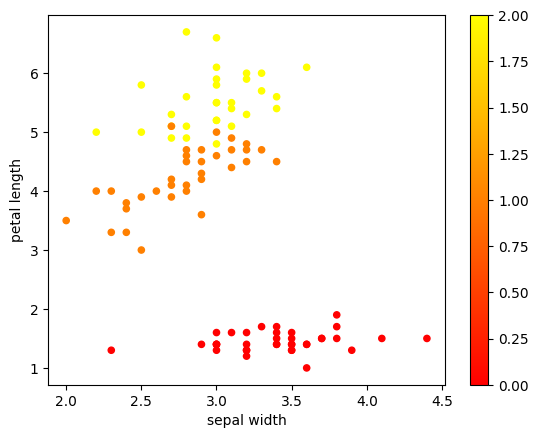

In [9]:
dim = ["sepal width","petal length"]
X_train.plot.scatter(x=dim[0],y=dim[1],c=y_train, colormap="autumn")

##### Recodons les classes pour avoir un problème de classification binaire avec les iris setosa d'un côté \(étiquette \-1\) et les iris versicolor et virignica de l'autre \(étiquette 1\). Visualisons les données avec les nouvelles classes.

Le nom de chaque classe est contenu dans le champ target_names du dictionnaire iris.



In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

<Axes: xlabel='sepal width', ylabel='petal length'>

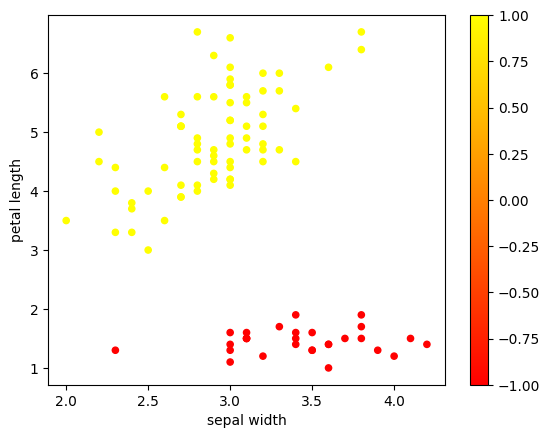

In [ ]:
y_train = y_train.replace([0,1,2],[-1,1,1])
y_test = y_test.replace([0,1,2],[-1,1,1])

X_train.plot.scatter(x=dim[0],y=dim[1],c=y_train, colormap="autumn")

#### Utilisons l'algorithme knn \(k=4\) pour séparer les 2 classes avec les 2 dimensions sélectionnés. Calculons l'erreur empirique et l'erreur en généralisation.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

clf_knn = KNeighborsClassifier(n_neighbors=4)

clf_knn.fit(X_train[dim],y_train)
print("Erreur empirique : ",1-clf_knn.score(X_train[dim],y_train))
print("Erreur en généralisation : ",1-clf_knn.score(X_test[dim],y_test))


Erreur empirique :  0.0
Erreur en généralisation :  0.0


Le modèle appris  sépare parfaitement les données. Ce n'est pas surprenant, nous sommes face à un problème séparable \(voir les visualisations précédentes\). En utilisant le code suivant, il est possible de visualiser la frontière de décision d'un classifieur pour des données en 2 dimensions.


In [ ]:
def visualize(clf,X1,X2,y):
    """ Permet de visualiser la frontière de décision du classificateur clf.

    Parameters
    ----------
    clf :
        Le classificateur à visualiser
    X1 :
        La première dimension des données
    X2 :
        La seconde dimension des données
    y :
        Les étiquettes des exemples

    """
    # Plotting decision regions
    x_min, x_max = np.array(X1).min() - 1, np.array(X1).max() + 1
    y_min, y_max = np.array(X2).min() - 1, np.array(X2).max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X1, X2, c=y, s=20, edgecolor='k')

    plt.show()

Visualisons la frontière de décision du classificateur Knn


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


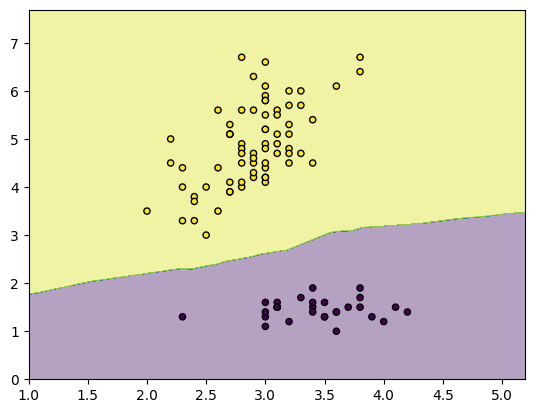

In [ ]:
import matplotlib.pyplot as plt
visualize(clf_knn,X_train[dim[0]],X_train[dim[1]],y_train)

### Classification de 4 ensembles de données gaussiennes  simulées à regrouper en  2 groupes



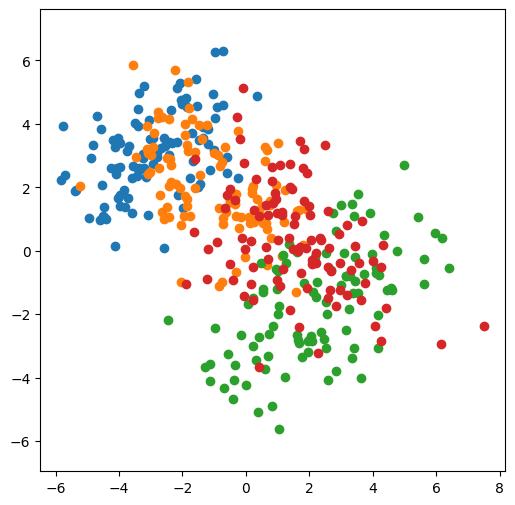

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
mean1 = [-3, 3]
cov1 = np.multiply([[1, 0.5], [0.5, 1]],2)
x1, y1 = np.random.multivariate_normal(mean1, cov1, 100).T
mean2 = [-1,2]
cov2 = np.multiply([[1, -0.5], [-0.5, 1]],2)
x2, y2 = np.random.multivariate_normal(mean2, cov2, 100).T
mean3 = [2, -2]
cov3 = np.multiply([[1, 0.5], [0.5, 1]],3)
x3, y3 = np.random.multivariate_normal(mean3, cov3, 100).T
mean4 = [2,0]
cov4 = np.multiply([[1, -0.5], [-0.5, 1]],3)
x4, y4 = np.random.multivariate_normal(mean4, cov4, 100).T
plt.plot(x1, y1, 'o')
plt.plot(x2,y2,'o')
plt.plot(x3, y3, 'o')
plt.plot(x4,y4,'o')
plt.plot()
plt.axis('equal')
plt.show()

In [ ]:
data1 = pd.DataFrame([x1,y1],index = ['x','y'])
data2=pd.DataFrame([x2,y2],index = ['x','y'])
data_l = pd.concat([data1,data2],axis=1,ignore_index=True)
data_l=data_l.T
data_l['group'] = 0
data_l.head()

,x,y,group
0,-3.830235,1.925916,0
1,-3.232586,3.059344,0
2,-3.811799,1.380975,0
3,-1.562879,5.430782,0
4,-4.412094,1.012456,0


In [ ]:
data3 = pd.DataFrame([x3,y3],index = ['x','y'])
data4=pd.DataFrame([x4,y4],index = ['x','y'])
data_r = pd.concat([data3,data4],axis=1,ignore_index=True)
data_r=data_r.T
data_r['group'] = 1
data_r.head()

,x,y,group
0,4.169585,-2.013217,1
1,0.234472,-3.016201,1
2,-0.960320,-2.428951,1
3,3.527347,1.791995,1
4,3.423643,-3.052259,1


<Axes: xlabel='x', ylabel='y'>

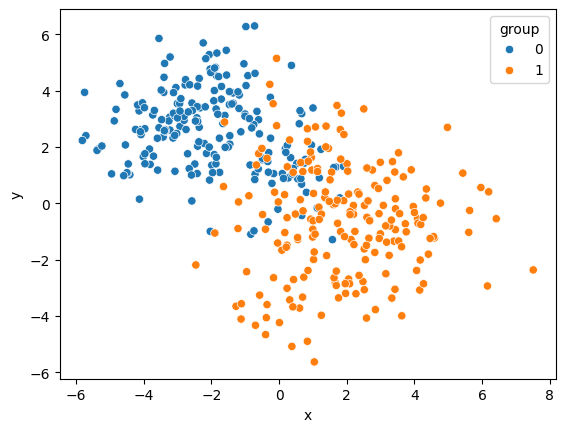

In [ ]:
data_groupees = pd.concat([data_l,data_r],ignore_index = True)
sns.scatterplot(data=data_groupees,x='x',y='y',hue='group')

### Zones de niveau et bornes de classification



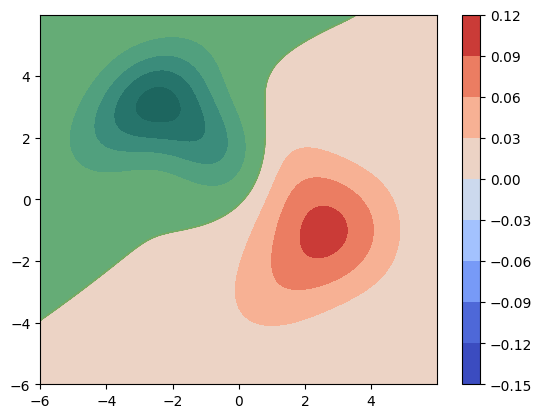

In [ ]:
from scipy.stats import multivariate_normal
xes ,ys = np.mgrid[-6:6:0.01,-6:6:0.01]
pos = np.dstack((xes,ys))
rv_1 = multivariate_normal(mean1,cov1)
pdf_1 = rv_1.pdf(pos)
rv_2 = multivariate_normal(mean2,cov2)
pdf_2 = rv_2.pdf(pos)


rv_3 = multivariate_normal(mean3,cov3)
pdf_3 = rv_3.pdf(pos)
rv_4 = multivariate_normal(mean4,cov4)
pdf_4 = rv_4.pdf(pos)
im = plt.contourf(xes,ys,-pdf_1-pdf_2+pdf_3+pdf_4,cmap = 'coolwarm', vmin = -0.12, vmax = 0.12)
plt.colorbar(im)
img = -pdf_1-pdf_2+pdf_3+pdf_4
x_bound , y_bound = np.where(img<0)
x_bound = x_bound/100 -6
y_bound = y_bound/100-6
plt.plot(x_bound,y_bound,color='g',alpha=0.5)

#### Borne de classification optimal de Bayes



Text(0.5, 1.0, 'Bayes Borne de décision')

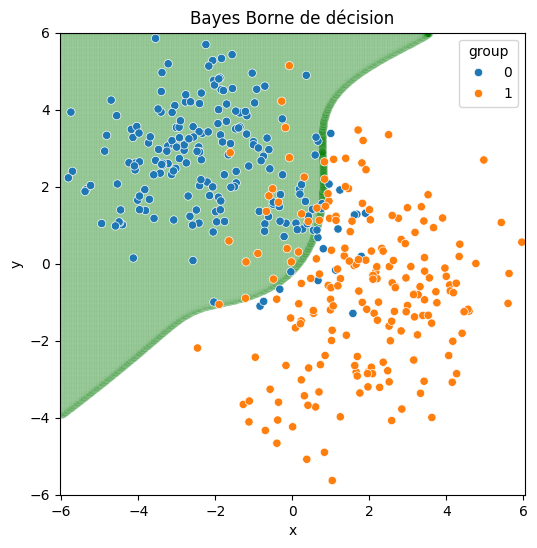

In [ ]:
plt.figure(figsize=(6,6))
ax = sns.scatterplot(x=x_bound,y=y_bound,color='g',alpha=0.1)
sns.scatterplot(data=data_groupees,x='x',y='y',hue='group')
ax.axis('equal')
ax.set(ylim=(-6,6))
ax.set(xlim=(-6,6))
ax.set_title('Bayes Borne de décision')

### Région de classification Knn et comparaison avec celui de Bayes



In [ ]:

from sklearn.neighbors import KNeighborsClassifier

ndat = data_groupees.to_numpy()
X = ndat[:,:2]

neigh = KNeighborsClassifier(n_neighbors=1)
neigh.fit(X,data_groupees['group'])

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(-6,6,0.01), np.arange(-6,6,0.01))
Z = neigh.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

Text(0.5, 1.0, 'KNN Borne de décision (k = 1), en comparaison avec celui de Bayes')

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


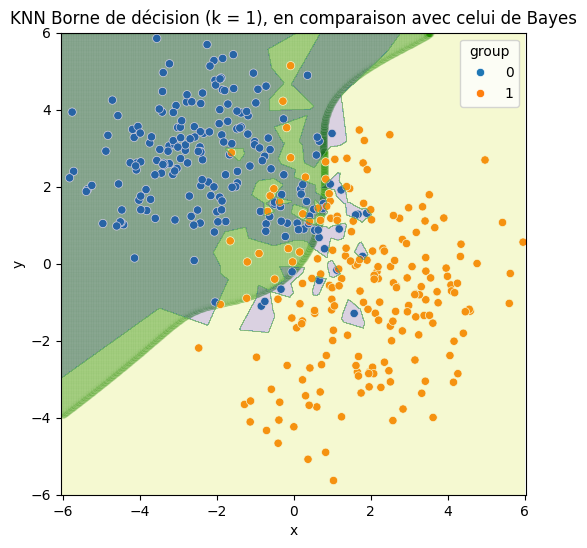

In [ ]:
plt.figure(figsize=(6,6))

ax = sns.scatterplot(x=x_bound,y=y_bound,color='g',alpha=0.1)
sns.scatterplot(data=data_groupees,x='x',y='y',hue='group')
plt.contourf(xx,yy,Z,alpha=0.2)
ax.axis('equal')
ax.set(ylim=(-6,6))
ax.set(xlim=(-6,6))

ax.set_title('KNN Borne de décision (k = 1), en comparaison avec celui de Bayes')

In [ ]:
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(X,data_groupees['group'])
Z = neigh.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

Text(0.5, 1.0, 'KNN Borne de décision (k = 10), en comparaison avec celui de Bayes')

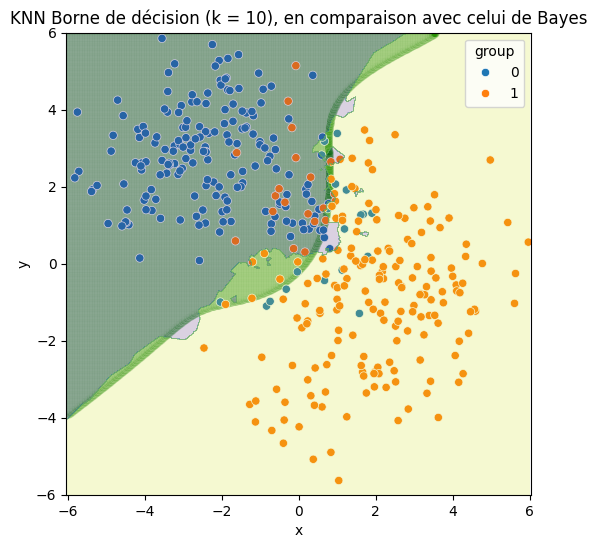

In [ ]:
plt.figure(figsize=(6,6))

ax = sns.scatterplot(x=x_bound,y=y_bound,color='g',alpha=0.1)
sns.scatterplot(data=data_groupees,x='x',y='y',hue='group')
plt.contourf(xx,yy,Z,alpha=0.2)
ax.axis('equal')
ax.set(ylim=(-6,6))
ax.set(xlim=(-6,6))

ax.set_title('KNN Borne de décision (k = 10), en comparaison avec celui de Bayes')

Text(0.5, 1.0, 'KNN Borne de décision (k = 100), en comparaison avec celui de Bayes')

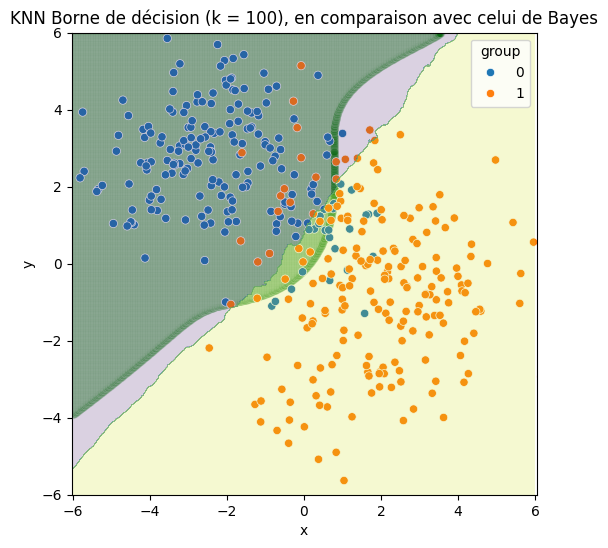

In [ ]:
neigh = KNeighborsClassifier(n_neighbors=100)
neigh.fit(X,data_groupees['group'])
Z = neigh.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,6))

ax = sns.scatterplot(x=x_bound,y=y_bound,color='g',alpha=0.1)
sns.scatterplot(data=data_groupees,x='x',y='y',hue='group')
plt.contourf(xx,yy,Z,alpha=0.2)
ax.axis('equal')
ax.set(ylim=(-6,6))
ax.set(xlim=(-6,6))

ax.set_title('KNN Borne de décision (k = 100), en comparaison avec celui de Bayes')

L'effet du nombre de voisins les plus proches peut être observé. Pour un nombre trop faible de voisins, les limites de décision ont un effet granulaire, identifiant de petites frontières qui n'existent pas dans les données originales \(issues de la limite de décision de Bayes\). Trop de voisins, et tous les détails de la frontière sont effacés. Le nombre optimal de voisins peut être trouvé en traçant le taux d'erreur de test par rapport à $k$ \(nombre de voisins\).


#### Exemple  1: Dataset Breast cancer

Utiliser le dataset `sklearn.datasets.load_breast_cancer.`

1. Chargez le dataset. Pourquoi un modèle de classification sur ce dataset est possible? Donner les instances et etiquettes.  Utilisez les deux tiers des données pour l'apprentissage.
2. Utilisez l'algorithme du sklearn.neighbors.KNeighborsClassifier pour apprendre un modèle. Optimiser le nombre de voisins à sélectionner. Quelle valeur vous semble la plus appropriée pour ce dataset ?
3. Calculez l'erreur empirique et l'erreur en généralisation des modèles appris par votre approche. Que constatez\-vous ?



In [ ]:
#1)
from sklearn.datasets import load_breast_cancer
breast_cancer = load_breast_cancer()
breast_cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(breast_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

Les instances sont décrites par 30 mesures quantitatives $X$ à valeurs dans $\in \mathbb{R}^30$. L'ensemble des étiquettes $Y$
est composé des $M=2$ types de tumeurs.

In [ ]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
X = pd.DataFrame(breast_cancer.data,columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=2/3)

Pour choisir le nombre de voisins à considérer, on va considérer que des nombres impairs de voisins, on peut aussi faire de la validation croisée

In [ ]:
cv = GridSearchCV(KNeighborsClassifier(),{"n_neighbors":[1,3, 5, 7,9, 10,15, 20, 25,30]},cv=5)
cv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7, 9, 10, 15, 20, 25, 30]})

In [ ]:
cv.best_params_

{'n_neighbors': 10}

In [ ]:
k = 10
clf = KNeighborsClassifier(n_neighbors=k)
clf.fit(X_train,y_train)
print("Erreur empirique : ",1-clf.score(X_train,y_train))
print("Erreur en généralisation : ",1-clf.score(X_test,y_test))

Erreur empirique :  0.04485488126649073
Erreur en généralisation :  0.0736842105263158


#### Exercice à faire pour mercredi 12 février: Dataset Two moons

1. Pourquoi un modèle de classification sur ce dataset est possible? Donner les instances et etiquettes.  Utilisez les deux tiers des données pour l'apprentissage.
2. Utilisez l'algorithme du sklearn.neighbors.KNeighborsClassifier pour apprendre un modèle. Optimiser le nombre de voisins à sélectionner. Quelle valeur vous semble la plus appropriée pour ce dataset ?
3. Calculez l'erreur empirique et l'erreur en généralisation des modèles appris par votre approche. Que constatez\-vous ?



In [ ]:
from sklearn.datasets import make_moons
moons = make_moons(1000,noise=0.1)
moons_data = pd.DataFrame(moons[0])
moons_target = pd.Series(moons[1])